# Ejercicio 1.
Genera una imagen semejante a una diana de tiro al blanco como se aprecia en la imagen a continuación
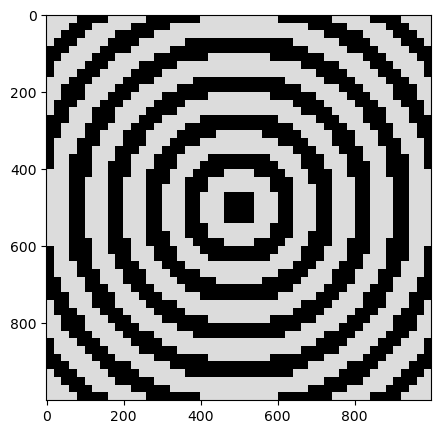


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Ejercicio 2.
Genera la imagen tal cual se muestra acontinuación, tomar en cuenta el tamaño 
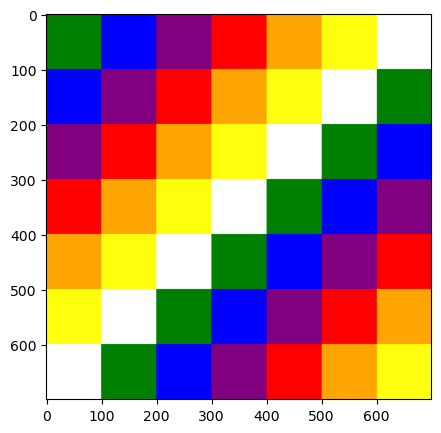

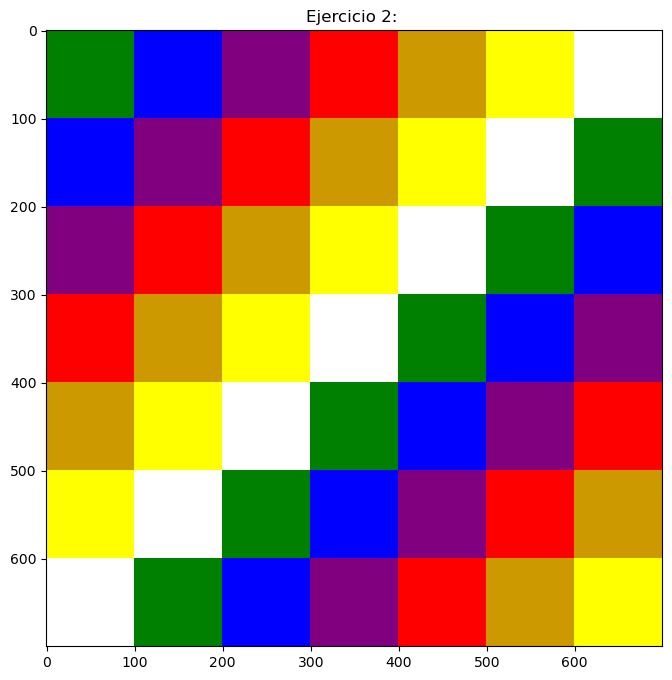

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

width_2, height_2 = 700, 700
img_grid = np.zeros((height_2, width_2, 3), dtype=np.uint8)

colores_base = [
    [0, 128, 0],
    [0, 0, 255],
    [128, 0, 128],
    [255, 0, 0],
    [204, 153, 0],
    [255, 255, 0],
    [255, 255, 255],
    [0, 128, 0],
    [0, 0, 255],
    [128, 0, 128],
    [255, 0, 0],
    [204, 153, 0],
    [255, 255, 0]
]
step = 100

for y in range(0, height_2, step):
    for x in range(0, width_2, step):
        i = x // step
        j = y // step
        indice_color = i + j
        if indice_color >= len(colores_base):
            indice_color = len(colores_base) - 1
        img_grid[y:y+step, x:x+step] = colores_base[indice_color]

plt.figure(figsize=(8, 8))
plt.imshow(img_grid)
plt.title('Ejercicio 2: ')
cv2.imwrite('grid_colores.png', cv2.cvtColor(img_grid, cv2.COLOR_RGB2BGR))
plt.show()

# Ejercicio 3.
Tomando en cuenta la imagen1.jpg elige un punto de interés al azar (funcion randomica), solariza y posteriza la imagen, realiza un tratamiento de umbralización(el de preferencia), mezcla tecnicas y obtiene un filtro artistico,lista todas las imágenes con sus correspondientes titulos, guarda todas las imágenes resultantes con sus nombres.

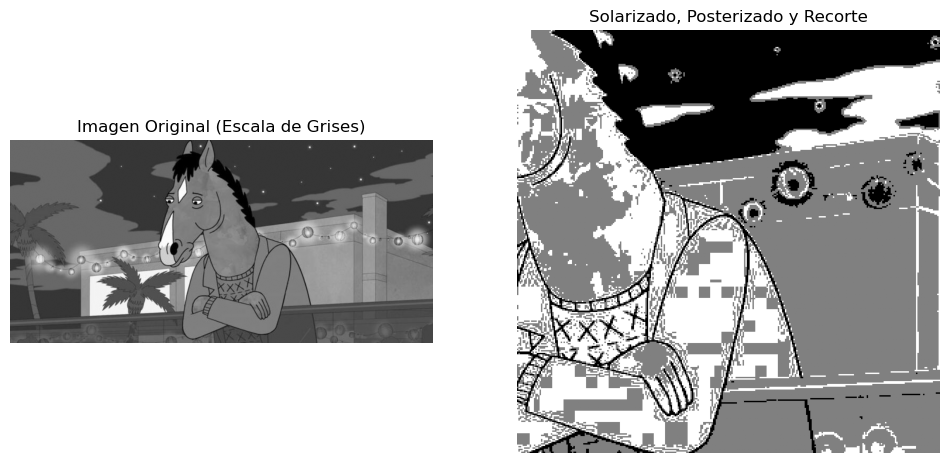

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

imagen3 = cv2.imread('imagen1.jpg', cv2.IMREAD_GRAYSCALE)
umbral_otsu, _ = cv2.threshold(imagen3, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
img_solarizada = np.where(imagen3 < umbral_otsu, imagen3, 255 - imagen3).astype(np.uint8)
niveles = 4
factor = 256 // niveles
img_posterizada = (img_solarizada // factor) * factor
h, w = img_posterizada.shape
crop_h, crop_w = 300, 300

crop_h = min(crop_h, h)
crop_w = min(crop_w, w)

y_rand = random.randint(0, h - crop_h)
x_rand = random.randint(0, w - crop_w)

recorte = img_posterizada[y_rand:y_rand+crop_h, x_rand:x_rand+crop_w]
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(imagen3, cmap='gray')
plt.title('Imagen Original (Escala de Grises) ')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(recorte, cmap='gray')
plt.title('Solarizado, Posterizado y Recorte')
plt.axis('off')

plt.show()

# Ejercicio 4.
Genera un avatar, basandote en una imagen tuya que usaste en practicas anteriores, este avatar debe tener filtros y/o umbralizaciones.
Guarda la imagen 

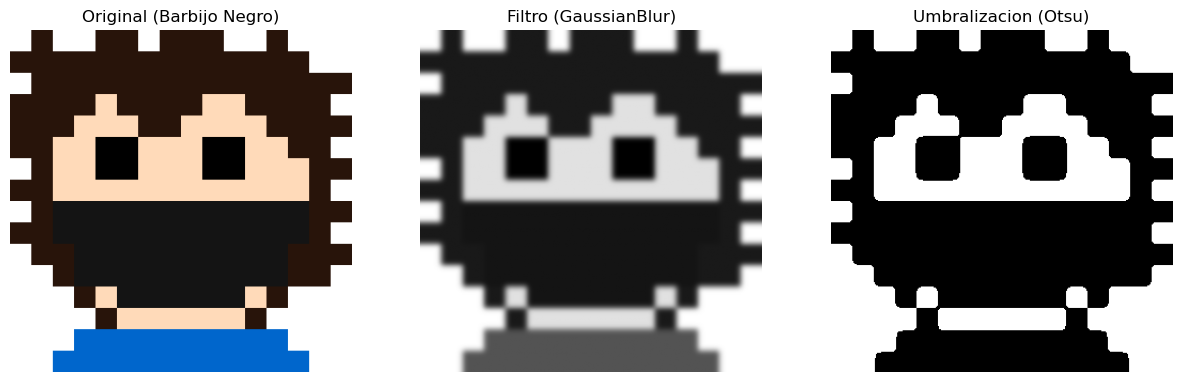

In [58]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

tamano = 320
step = 20

img_grid = np.zeros((tamano, tamano, 3), dtype=np.uint8)

diseno = [
    [0,1,0,0,1,1,0,1,1,1,0,0,1,0,0,0],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
    [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,2,1,1,1,1,2,2,1,1,1,1,0],
    [1,1,1,2,2,2,1,1,2,2,2,2,1,1,1,1],
    [1,1,2,2,3,3,2,2,2,3,3,2,2,1,1,0],
    [0,1,2,2,3,3,2,2,2,3,3,2,2,2,1,1],
    [1,1,2,2,2,2,2,2,2,2,2,2,2,2,1,0],
    [0,1,4,4,4,4,4,4,4,4,4,4,4,4,1,1],
    [1,1,4,4,4,4,4,4,4,4,4,4,4,4,1,0],
    [0,1,1,4,4,4,4,4,4,4,4,4,4,1,1,1],
    [0,0,1,4,4,4,4,4,4,4,4,4,4,1,1,0],
    [0,0,0,1,2,4,4,4,4,4,4,2,1,0,0,0],
    [0,0,0,0,1,2,2,2,2,2,2,1,0,0,0,0],
    [0,0,0,5,5,5,5,5,5,5,5,5,5,0,0,0],
    [0,0,5,5,5,5,5,5,5,5,5,5,5,5,0,0]
]

colores = {
    0: [255, 255, 255],
    1: [40, 20, 10],
    2: [255, 218, 185],
    3: [0, 0, 0],
    4: [20, 20, 20],
    5: [0, 102, 204]
}

for y in range(0, tamano, step):
    for x in range(0, tamano, step):
        i = x // step
        j = y // step
        img_grid[y:y+step, x:x+step] = colores[diseno[j][i]]

img_gray = cv2.cvtColor(img_grid, cv2.COLOR_RGB2GRAY)

img_blur = cv2.GaussianBlur(img_gray, (15, 15), 0)

_, img_otsu = cv2.threshold(img_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_grid)
plt.title('Original (Barbijo Negro)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_blur, cmap='gray')
plt.title('Filtro (GaussianBlur)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_otsu, cmap='gray')
plt.title('Umbralizacion (Otsu)')
plt.axis('off')

plt.savefig('comparativa_avatar.png', bbox_inches='tight')

cv2.imwrite('avatar_color.png', cv2.cvtColor(img_grid, cv2.COLOR_RGB2BGR))
cv2.imwrite('avatar_otsu.png', img_otsu)

plt.show()